In [1]:
import os
# Tensorflow trop bavard pour moi
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import yaml
from tensorflow import keras
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

our models and our yaml config are imported

In [2]:
ae = tf.keras.models.load_model('training/ae_mnist.keras')
decoder = ae.get_layer('functional_1')
encoder = ae.get_layer('functional')

with open("configs/ae_config.yaml", "r") as f:
    config = yaml.safe_load(f)

we prepare the data to do some tests

In [3]:
mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

x_train = np.pad(x_train, ((0,0), (2,2), (2,2), (0,0)), mode='constant')
x_test = np.pad(x_test, ((0,0), (2,2), (2,2), (0,0)), mode='constant')

let's test our generator. To do that a 7 is generated and in 10 images it's slightly turned into a 2. it seems to work pretty well

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


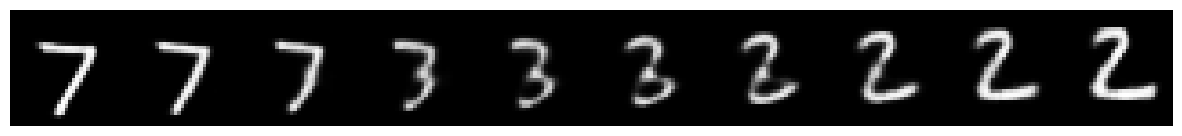

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [4]:
code_A = encoder.predict(x_test[0:1])
code_B = encoder.predict(x_test[1:2])

steps = 10
grid = np.zeros((32, 32 * steps))

for i in range(steps):
    alpha = i / (steps - 1)
    inter_code = (1 - alpha) * code_A + alpha * code_B
    inter_img = decoder.predict(inter_code)
    grid[:, i*32:(i+1)*32] = inter_img.reshape(32, 32)

plt.figure(figsize=(15, 5))
plt.imshow(grid, cmap='gray')
plt.axis('off')
plt.show()

latent_dim = config['model_params']['latent_dim']
code_A = encoder.predict(x_test[0:1])
code_B = np.random.normal(size=(1, latent_dim))

However if now we decide to go from a random point to another radom point the model seems to give weird results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


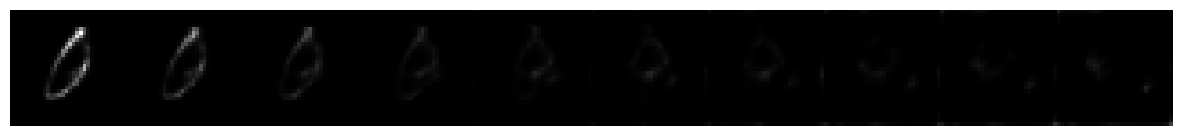

In [5]:
latent_dim = config['model_params']['latent_dim']
code_A = np.random.normal(size=(1, latent_dim))
code_B = np.random.normal(size=(1, latent_dim))

steps = 10
grid = np.zeros((32, 32 * steps))

for i in range(steps):
    alpha = i / (steps - 1)
    inter_code = (1 - alpha) * code_A + alpha * code_B
    inter_img = decoder.predict(inter_code)
    grid[:, i*32:(i+1)*32] = inter_img.reshape(32, 32)

plt.figure(figsize=(15, 5))
plt.imshow(grid, cmap='gray')
plt.axis('off')
plt.show()

To see the issue we decide to project the 10 dimensions od the latent space in 2 dimensions. First with the 2 more importants dimensions with PCA.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step


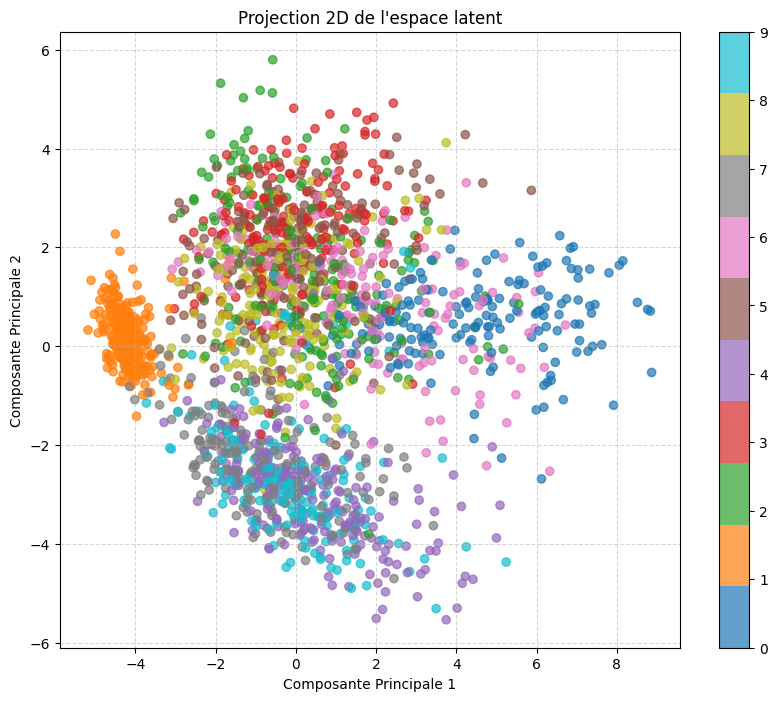

In [6]:
n_samples = 2000
codes_latents = encoder.predict(x_test[:n_samples])

pca = PCA(n_components=2)
codes_2d = pca.fit_transform(codes_latents)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(codes_2d[:, 0], codes_2d[:, 1], c=y_test[:n_samples], cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title("Projection 2D de l'espace latent")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

We notice that this is a mess and we can also notice that there is some space with nothing in it. To have a better conclusion let's see what we have when we try to represent the distances between the points in 10 dimensions into a 2D projection.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 697us/step


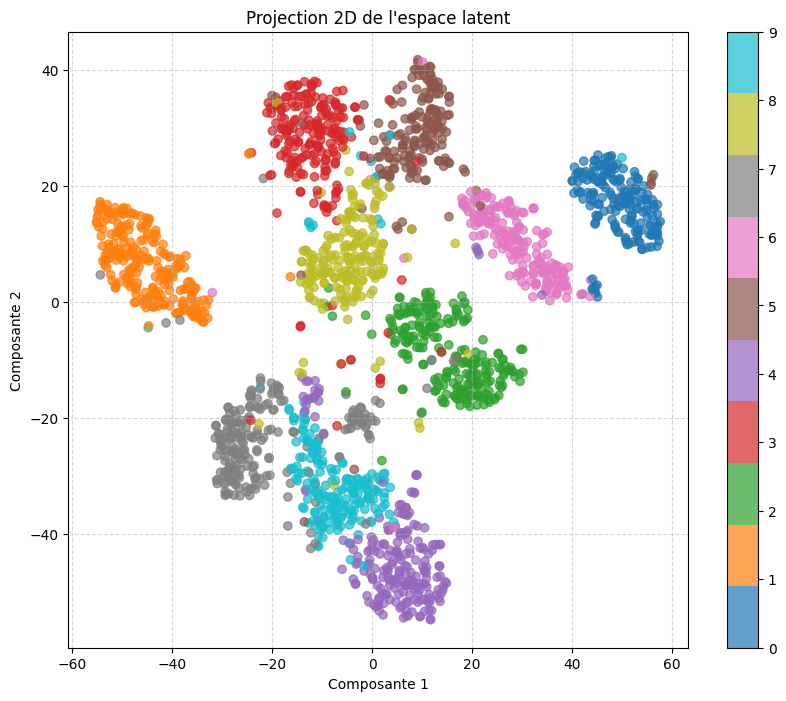

In [7]:
n_samples = 2000
codes_latents = encoder.predict(x_test[:n_samples])

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
codes_2d = tsne.fit_transform(codes_latents)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(codes_2d[:, 0], codes_2d[:, 1], c=y_test[:n_samples], cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title("Projection 2D de l'espace latent")
plt.xlabel("Composante 1")
plt.ylabel("Composante 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

There is interesting thing to say, first we now see the the clusters. Second we are sure now there is an issue of space it would be more interesting to have our points more distributed in the space; That explains the werid result of the random points in the space. Let's see how the VAE can produce better results